# Pediatric Pneumonia Diagnosis (Pneumonia vs Normal)


## 1. Imports and configuration

In [4]:
import os, re, shutil, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

SEED = 42
LEARNING_RATE = 0.001   # lowered from 0.01 — see note below
EPOCHS = 15
IMG_SIZE = (224, 224)
BATCH = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Config -> learning rate:", LEARNING_RATE, "| epochs:", EPOCHS)

Config -> learning rate: 0.001 | epochs: 15


## 2. Load dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/chest_xray"   # change to your actual path
assert os.path.exists(DATA_DIR), f"Path not found: {DATA_DIR}"
print(os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['val', 'test', 'train']


## 3. Build manifest and check patient overlap (leakage check)

In [6]:
def extract_patient_id(filename, label):
    if label == "PNEUMONIA":
        m = re.match(r"(person\d+)", filename)
        return m.group(1) if m else filename
    else:
        m = re.search(r"(IM-\d+)", filename)
        return m.group(1) if m else filename

def build_manifest(base_dir):
    records = []
    for split in ["train", "val", "test"]:
        for cls in ["NORMAL", "PNEUMONIA"]:
            folder = os.path.join(base_dir, split, cls)
            for fname in os.listdir(folder):
                records.append({
                    "filepath": os.path.join(folder, fname),
                    "filename": fname,
                    "label": cls,
                    "patient_id": extract_patient_id(fname, cls),
                    "orig_split": split
                })
    return pd.DataFrame(records)

manifest = build_manifest(DATA_DIR)
print(manifest.head())
print("Label counts:\n", manifest["label"].value_counts())

train_patients = set(manifest[manifest.orig_split == "train"].patient_id)
test_patients = set(manifest[manifest.orig_split == "test"].patient_id)
overlap = train_patients & test_patients
print("Patients found in both original train and test:", len(overlap))

                                            filepath                filename  \
0  /content/drive/MyDrive/chest_xray/train/NORMAL...  IM-0533-0001-0002.jpeg   
1  /content/drive/MyDrive/chest_xray/train/NORMAL...       IM-0540-0001.jpeg   
2  /content/drive/MyDrive/chest_xray/train/NORMAL...  IM-0499-0001-0002.jpeg   
3  /content/drive/MyDrive/chest_xray/train/NORMAL...       IM-0526-0001.jpeg   
4  /content/drive/MyDrive/chest_xray/train/NORMAL...       IM-0525-0001.jpeg   

    label patient_id orig_split  
0  NORMAL    IM-0533      train  
1  NORMAL    IM-0540      train  
2  NORMAL    IM-0499      train  
3  NORMAL    IM-0526      train  
4  NORMAL    IM-0525      train  
Label counts:
 label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64
Patients found in both original train and test: 264


## 4. Remove corrupt/empty images

In [7]:
def is_valid_image(fpath):
    try:
        raw = tf.io.read_file(fpath)
        img = tf.image.decode_jpeg(raw, channels=3)
        return img.shape[0] > 0 and img.shape[1] > 0
    except Exception:
        return False

manifest["valid"] = manifest["filepath"].apply(is_valid_image)
print("Corrupt files found:", (~manifest["valid"]).sum())

for f in manifest.loc[~manifest["valid"], "filepath"]:
    if os.path.exists(f):
        os.remove(f)

manifest = manifest[manifest["valid"]].drop(columns=["valid"]).reset_index(drop=True)

Corrupt files found: 0


## 5. Class distribution chart

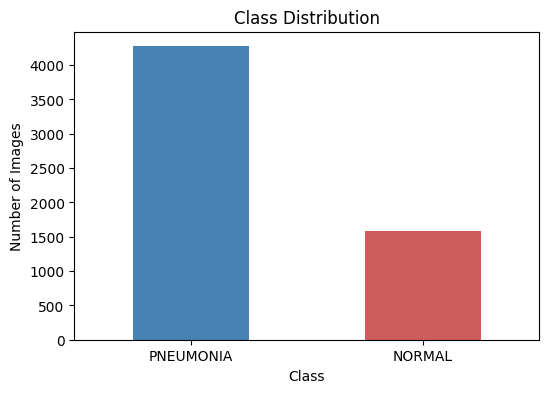

In [8]:
plt.figure(figsize=(6, 4))
manifest["label"].value_counts().plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

## 6. Patient-level train/val/test split

In [9]:
def split_patients(patient_ids, val_size=0.15, test_size=0.15, random_state=42):
    rng = np.random.default_rng(seed=random_state)
    ids = np.array(patient_ids)
    rng.shuffle(ids)
    n_val = int(len(ids) * val_size)
    n_test = int(len(ids) * test_size)
    return ids[n_val + n_test:], ids[:n_val], ids[n_val:n_val + n_test]   # train, val, test

train_ids, val_ids, test_ids = split_patients(manifest["patient_id"].unique(), random_state=SEED)
train_ids, val_ids, test_ids = set(train_ids), set(val_ids), set(test_ids)

def assign_split(pid):
    if pid in train_ids: return "train"
    if pid in val_ids: return "val"
    return "test"

manifest["new_split"] = manifest["patient_id"].apply(assign_split)
print(manifest.groupby(["new_split", "label"]).size())

assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids)
print("No patient overlap between splits.")

new_split  label    
test       NORMAL        215
           PNEUMONIA     668
train      NORMAL       1141
           PNEUMONIA    2937
val        NORMAL        227
           PNEUMONIA     668
dtype: int64
No patient overlap between splits.


## 7. Copy images into the new split folders

In [10]:
NEW_DIR = "/content/chest_xray_clean"
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        os.makedirs(os.path.join(NEW_DIR, split, cls), exist_ok=True)

for _, row in manifest.iterrows():
    dest = os.path.join(NEW_DIR, row.new_split, row.label, row.filename)
    if not os.path.exists(dest):
        shutil.copy(row.filepath, dest)

print("Done.")

Done.


## 8. Preprocessing (fit/augment only on train)

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{NEW_DIR}/train", image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary", seed=SEED)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{NEW_DIR}/val", image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary", seed=SEED)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{NEW_DIR}/test", image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary", shuffle=False)

class_names = ["NORMAL", "PNEUMONIA"]
normalization = layers.Rescaling(1./255)
augment = tf.keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.05)])

def preprocess(ds, training=False):
    ds = ds.map(lambda x, y: (normalization(x), y))
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y))
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds_p = preprocess(train_ds, training=True)
val_ds_p = preprocess(val_ds)
test_ds_p = preprocess(test_ds)

y_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0).ravel()

Found 4078 files belonging to 2 classes.
Found 895 files belonging to 2 classes.
Found 883 files belonging to 2 classes.


## 9. Baseline — majority class

In [12]:
majority_class = pd.Series(y_test).mode()[0]
baseline_preds = np.full(y_test.shape, majority_class)
baseline_accuracy = (baseline_preds == y_test).mean()
print("Baseline accuracy:", baseline_accuracy)
print(classification_report(y_test, baseline_preds, target_names=class_names, zero_division=0))

Baseline accuracy: 0.7565118912797282
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       215
   PNEUMONIA       0.76      1.00      0.86       668

    accuracy                           0.76       883
   macro avg       0.38      0.50      0.43       883
weighted avg       0.57      0.76      0.65       883



## 10. Class weights

In [13]:
n_normal = len(os.listdir(f"{NEW_DIR}/train/NORMAL"))
n_pneumonia = len(os.listdir(f"{NEW_DIR}/train/PNEUMONIA"))
total = n_normal + n_pneumonia
class_weight = {0: total / (2 * n_normal), 1: total / (2 * n_pneumonia)}
print("Class weights:", class_weight)

Class weights: {0: 1.7870289219982471, 1: 0.6942458290772897}


## 11. Model 1 — Simple CNN

In [14]:
def build_simple_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", name="last_conv"), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

cnn_model = build_simple_cnn()
cnn_model.summary()

start = time.time()
history_cnn = cnn_model.fit(train_ds_p, validation_data=val_ds_p,
                             epochs=EPOCHS, class_weight=class_weight)
print("CNN training time (s):", round(time.time() - start, 1))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.4568 - auc: 0.5372 - loss: 0.6914 - val_accuracy: 0.5743 - val_auc: 0.6766 - val_loss: 0.6963
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.6054 - auc: 0.7063 - loss: 0.6322 - val_accuracy: 0.5553 - val_auc: 0.8743 - val_loss: 0.7048
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.7391 - auc: 0.8198 - loss: 0.5179 - val_accuracy: 0.2715 - val_auc: 0.9085 - val_loss: 1.4042
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 334s 3s/step - accuracy: 0.7761 - auc: 0.8691 - loss: 0.4426 - val_accuracy: 0.8235 - val_auc: 0.9035 - val_loss: 0.3871
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.7987 - auc: 0.8866 - loss: 0.4143 - val_accuracy: 0.7777 - val_auc: 0.9070 - val_loss: 0.4465
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.7960 - auc: 0.8894 - loss: 0.4099 - val_accuracy: 0.7955 - val_auc: 0.9067 - val_loss: 0.4089
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━

## 12. Model 2 — Transfer Learning (MobileNetV2)

In [15]:
def build_transfer_model():
    base = applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs=base.input, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

tl_model = build_transfer_model()

start = time.time()
history_tl = tl_model.fit(train_ds_p, validation_data=val_ds_p,
                           epochs=EPOCHS, class_weight=class_weight)
print("Transfer learning training time (s):", round(time.time() - start, 1))

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.7997 - auc: 0.8878 - loss: 0.4218 - val_accuracy: 0.9140 - val_auc: 0.9743 - val_loss: 0.2324
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.8987 - auc: 0.9653 - loss: 0.2480 - val_accuracy: 0.9162 - val_auc: 0.9800 - val_loss: 0.2086
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9076 - auc: 0.9733 - loss: 0.2146 - val_accuracy: 0.9307 - val_auc: 0.9824 - val_loss: 0.1792
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.9154 - auc: 0.9748 - loss: 0.2054 - val_accuracy: 0.9207 - val_auc: 0.9828 - val_loss: 0.2036
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.9203 - auc: 0.9789 - loss: 0.1893 - val_accuracy: 0.9240 - val_auc: 0.9837 - val_loss: 0.1901
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.9255 - auc: 0.9801 - loss: 0.1818 - val_accuracy: 0.9397 - val_auc: 0.9838 - val_loss: 0.1682
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━

## 13. Evaluation on the test set

28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 744ms/step

--- Simple CNN ---
Accuracy: 0.7361268403171007
              precision    recall  f1-score   support

      NORMAL       0.48      0.99      0.65       215
   PNEUMONIA       0.99      0.66      0.79       668

    accuracy                           0.74       883
   macro avg       0.74      0.82      0.72       883
weighted avg       0.87      0.74      0.75       883

ROC-AUC: 0.9220373207074224


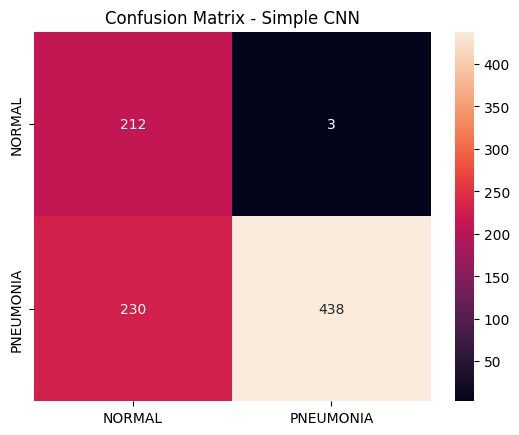

28/28 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step

--- Transfer Learning ---
Accuracy: 0.9331823329558324
              precision    recall  f1-score   support

      NORMAL       0.80      0.96      0.88       215
   PNEUMONIA       0.99      0.92      0.95       668

    accuracy                           0.93       883
   macro avg       0.89      0.94      0.91       883
weighted avg       0.94      0.93      0.94       883

ROC-AUC: 0.9822726639743768


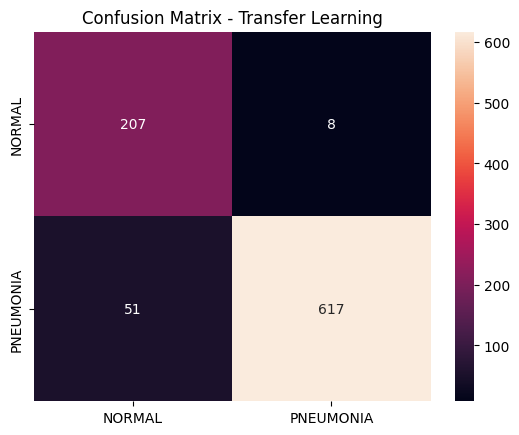

In [16]:
def evaluate_model(model, ds, name):
    y_true = np.concatenate([y.numpy() for _, y in ds], axis=0).ravel()
    y_prob = model.predict(preprocess(ds)).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    print(f"\n--- {name} ---")
    print("Accuracy:", (y_pred == y_true).mean())
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return y_true, y_prob

y_true_cnn, y_prob_cnn = evaluate_model(cnn_model, test_ds, "Simple CNN")
y_true_tl, y_prob_tl = evaluate_model(tl_model, test_ds, "Transfer Learning")

## 14. ROC curve comparison

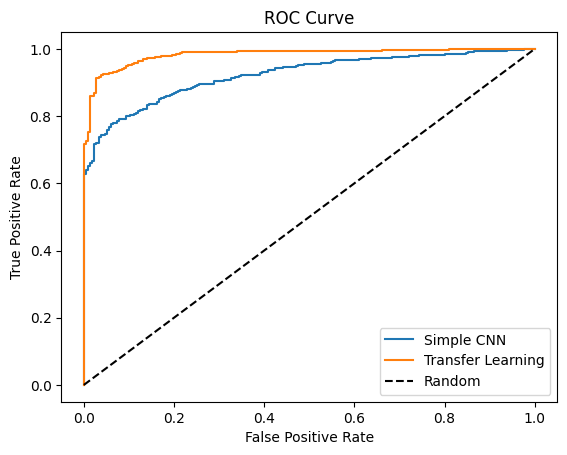

In [17]:
fpr_cnn, tpr_cnn, _ = roc_curve(y_true_cnn, y_prob_cnn)
fpr_tl, tpr_tl, _ = roc_curve(y_true_tl, y_prob_tl)

plt.plot(fpr_cnn, tpr_cnn, label="Simple CNN")
plt.plot(fpr_tl, tpr_tl, label="Transfer Learning")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.show()

## 15. Novelty evidence — leaky split vs patient-level split


In [28]:
leaky_train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train", image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary", seed=SEED)
leaky_val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/val", image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary", seed=SEED)
leaky_test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test", image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary", shuffle=False)

leaky_model = build_simple_cnn()
leaky_model.fit(preprocess(leaky_train_ds, training=True),
                 validation_data=preprocess(leaky_val_ds),
                 epochs=EPOCHS, class_weight=class_weight, verbose=0)

y_leaky_true = np.concatenate([y.numpy() for _, y in leaky_test_ds], axis=0).ravel()
y_leaky_prob = leaky_model.predict(preprocess(leaky_test_ds)).ravel()
leaky_accuracy = ((y_leaky_prob > 0.5).astype(int) == y_leaky_true).mean()
clean_accuracy = ((y_prob_cnn > 0.5).astype(int) == y_true_cnn).mean()

comparison = pd.DataFrame({
    "Split type": ["Original (leaky)", "Patient-level (fixed)"],
    "Test Accuracy": [leaky_accuracy, clean_accuracy],
    "Train-Test patient overlap": [len(overlap), 0]
})
print(comparison)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 712ms/step
              Split type  Test Accuracy  Train-Test patient overlap
0       Original (leaky)       0.793269                         264
1  Patient-level (fixed)       0.736127                           0


## 16. Grad-CAM (model interpretation)

IM-0555-0001-0001.jpeg - P(pneumonia) = 0.003


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_14']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_52523/341084654.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")(np.arange(256))[:, :3]


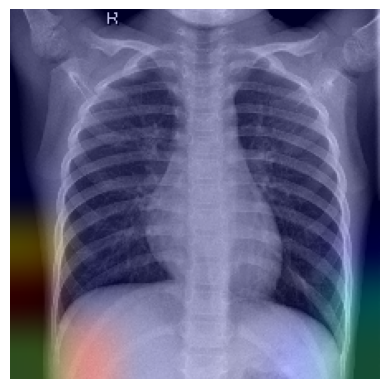

IM-0588-0001.jpeg - P(pneumonia) = 0.006


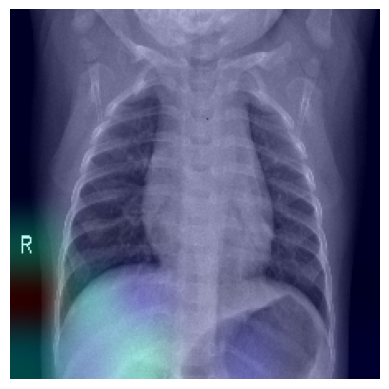

In [20]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    return (tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)).numpy()

def show_gradcam(filepath, heatmap):
    img = tf.keras.utils.img_to_array(tf.keras.utils.load_img(filepath, target_size=IMG_SIZE))
    heat = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heat = tf.keras.utils.array_to_img(jet[heat]).resize(IMG_SIZE)
    jet_heat = tf.keras.utils.img_to_array(jet_heat)
    plt.imshow(tf.keras.utils.array_to_img(jet_heat * 0.4 + img))
    plt.axis("off")
    plt.show()

for p in manifest[manifest.new_split == "test"]["filepath"].tolist()[:2]:
    arr = np.expand_dims(tf.keras.utils.img_to_array(tf.keras.utils.load_img(p, target_size=IMG_SIZE)) / 255.0, 0)
    pred = tl_model.predict(arr, verbose=0)[0][0]
    print(f"{os.path.basename(p)} - P(pneumonia) = {pred:.3f}")
    show_gradcam(p, make_gradcam_heatmap(arr, tl_model, "out_relu"))

## 17. Test with a new uploaded image

Saving person1952_bacteria_4883.jpeg to person1952_bacteria_4883.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


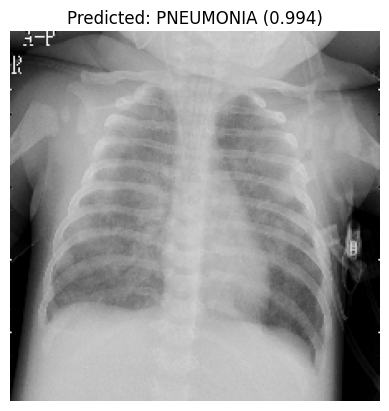

In [27]:
from google.colab import files

uploaded = files.upload()
fname = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(fname, target_size=IMG_SIZE)
arr = np.expand_dims(tf.keras.utils.img_to_array(img) / 255.0, 0)

prob = tl_model.predict(arr)[0][0]
label = "PNEUMONIA" if prob > 0.5 else "NORMAL"

plt.imshow(img); plt.axis("off")
plt.title(f"Predicted: {label} ({prob:.3f})")
plt.show()

## 18. Save models

In [25]:
cnn_model.save("/content/drive/MyDrive/simple_cnn_model.keras")
tl_model.save("/content/drive/MyDrive/transfer_model.keras")
print("Saved.")

Saved.
